In [1]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print('PyTorch version :', torch.__version__)
print('GPU disponible  :', torch.cuda.is_available())

# Ruta base del dataset en Kaggle
DATA_DIR = Path('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray')

# Verificar que existe
for split in ['train', 'val', 'test']:
    path = DATA_DIR / split
    classes = list(path.iterdir())
    total = sum(len(list(c.iterdir())) for c in classes)
    print(f'{split:5s}: {total:5d} imágenes  {[c.name for c in classes]}')


PyTorch version : 2.9.0+cpu
GPU disponible  : False
train:  5216 imágenes  ['PNEUMONIA', 'NORMAL']
val  :    16 imágenes  ['PNEUMONIA', 'NORMAL']
test :   624 imágenes  ['PNEUMONIA', 'NORMAL']


# Día 1 — Actividad: Regresión Logística en Chest X-Ray

En el notebook anterior aplicaste regresión logística a un problema 2D sintético (half-moons). Ahora vas a aplicar **exactamente el mismo modelo** a un problema real: detectar neumonía en radiografías de tórax.

### El problema
Cada imagen es una radiografía de tórax de 224×224 píxeles con 3 canales. Para aplicar regresión logística, la vas a **aplanar** a un vector de `224 × 224 × 3 = 150,528` valores — exactamente como hacíamos con los 2 features del dataset half-moons, pero ahora con 150,528.

El modelo sigue siendo el mismo:
$$\hat{p} = \sigma(w^\top x + b)$$

- $x \in \mathbb{R}^{150528}$ — imagen aplanada
- $w \in \mathbb{R}^{150528}$ — pesos
- $b \in \mathbb{R}$ — bias
- $\hat{p} \in (0,1)$ — probabilidad de PNEUMONIA

### Tu tarea
1. Completa la celda de entrenamiento iterando sobre el `train_dataloader` y `val_dataloader` del `ChestXRayDataModule`
2. Entrena durante 5 épocas
3. Al final, visualiza las imágenes mal clasificadas del test set

### Lo que deberías observar
El modelo va a aprender algo — no será completamente aleatorio. Pero tendrá un techo bajo porque una línea recta en un espacio de 150,528 dimensiones no puede capturar las estructuras visuales que diferencian una radiografía normal de una con neumonía. Eso es exactamente lo que motiva agregar capas ocultas en el día 2.

> **Nota sobre el desbalance:** hay más imágenes de PNEUMONIA que NORMAL en el dataset. El modelo puede alcanzar ~74% de accuracy simplemente prediciendo siempre PNEUMONIA. Ten esto en cuenta al interpretar tus resultados.

---
## Exploración del dataset

Antes de construir el DataModule, siempre vale la pena mirar los datos.

In [3]:
# Distribución de clases en train
train_dir = DATA_DIR / 'train'
for cls in sorted(train_dir.iterdir()):
    count = len(list(cls.iterdir()))
    bar   = '█' * (count // 100)
    print(f'{cls.name:12s}: {count:5d}  {bar}')

# Nota: el dataset está desbalanceado — hay más casos de PNEUMONIA que NORMAL
# Esto es importante para elegir la métrica correcta (no solo accuracy)

NORMAL      :  1341  █████████████
PNEUMONIA   :  3875  ██████████████████████████████████████


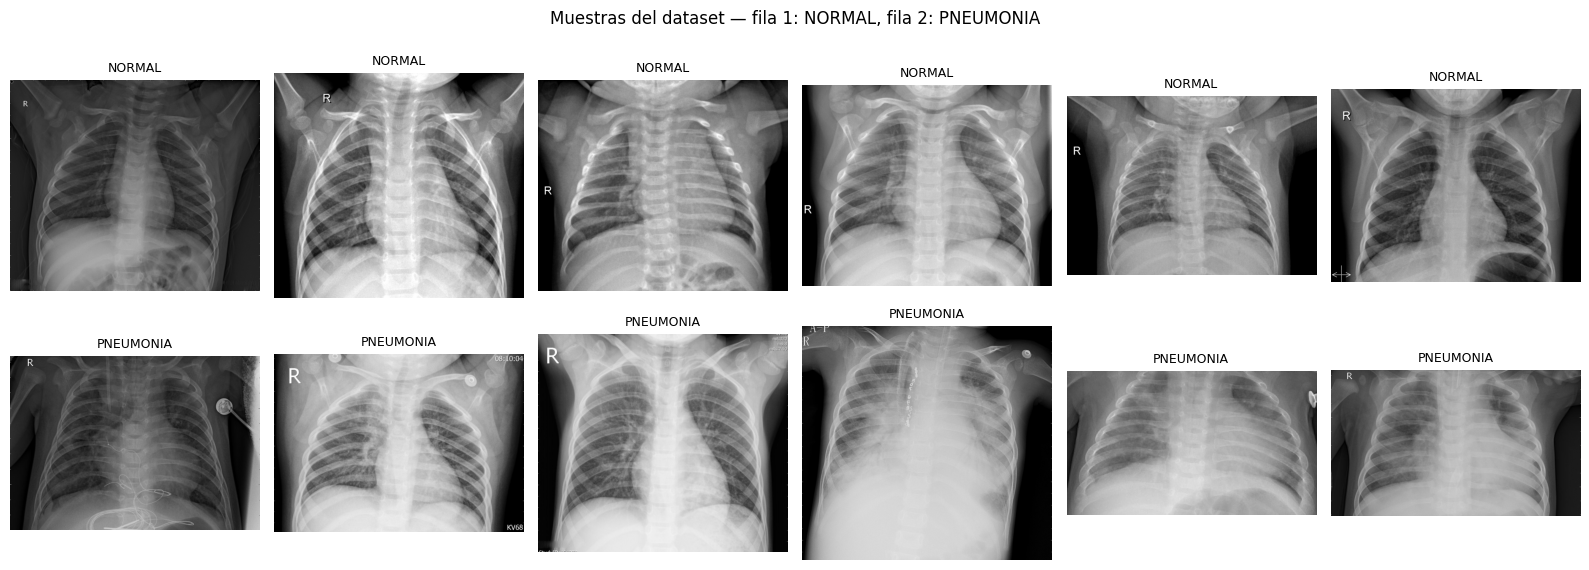

In [4]:
from PIL import Image

fig, axes = plt.subplots(2, 6, figsize=(16, 6))

for row, cls in enumerate(['NORMAL', 'PNEUMONIA']):
    images = list((train_dir / cls).iterdir())[:6]
    for col, img_path in enumerate(images):
        img = Image.open(img_path).convert('L')  # escala de grises
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(cls, fontsize=9)
        axes[row, col].axis('off')

plt.suptitle('Muestras del dataset — fila 1: NORMAL, fila 2: PNEUMONIA')
plt.tight_layout()
plt.show()

---
## Transforms

Definimos los transforms **antes** de los DataModules porque ambas versiones los comparten.

### Por qué transforms diferentes para train y val/test
- **Train:** aplicamos augmentación (flip, rotación, zoom) para que el modelo generalice mejor y no memorice las imágenes
- **Val/Test:** solo redimensionamos y normalizamos — nunca augmentamos datos de evaluación porque queremos medir el rendimiento real

In [6]:
IMG_SIZE = 224   # tamaño estándar para modelos de visión

# Media y std de ImageNet — usamos estas porque son estándar para imágenes médicas
# aun siendo en escala de grises (replicamos el canal 3 veces)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),   # replicar canal para modelos RGB
    transforms.RandomHorizontalFlip(),             # augmentación: flip horizontal
    transforms.RandomRotation(10),                 # augmentación: rotación ±10°
    transforms.RandomResizedCrop(IMG_SIZE,         # augmentación: zoom aleatorio
                                  scale=(0.85, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print('Train transforms :', train_transforms)
print('\nVal/Test transforms:', val_test_transforms)

Train transforms : Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    Grayscale(num_output_channels=3)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val/Test transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    Grayscale(num_output_channels=3)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


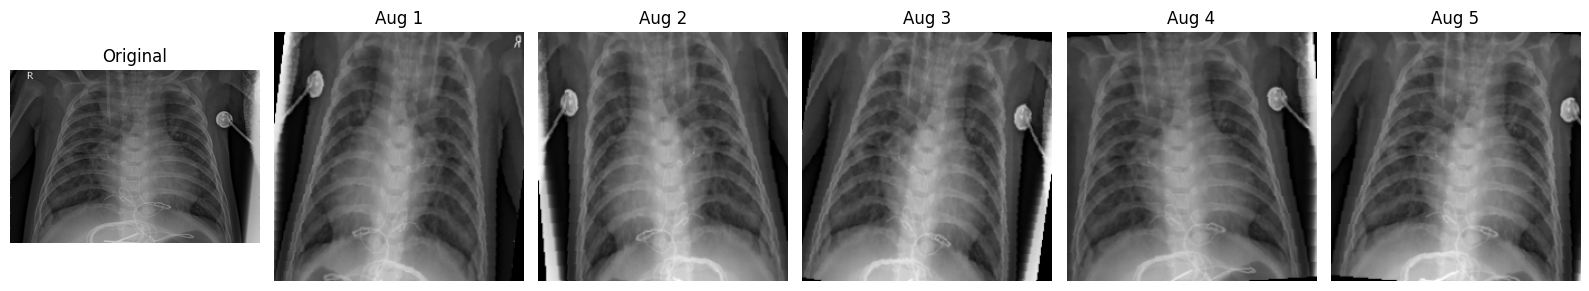

In [7]:
# Visualizar el efecto de la augmentación
from PIL import Image

sample_path = list((train_dir / 'PNEUMONIA').iterdir())[0]
sample_img = Image.open(sample_path)

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(1, 6):
    augmented = train_transforms(sample_img).permute(1, 2, 0).numpy()   # nombre correcto
    # Desnormalizar para visualizar
    augmented = augmented * np.array(STD) + np.array(MEAN)
    augmented = np.clip(augmented, 0, 1)
    axes[i].imshow(augmented[:, :, 0], cmap='gray')
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

---
# Parte 1 — DataModule en PyTorch Puro

In [8]:
class ChestXRayDataModule:
    """
    DataModule para Chest X-Ray en PyTorch puro.

    Usa ImageFolder que asume esta estructura de directorios:
        split/
            NORMAL/     ← clase 0
            PNEUMONIA/  ← clase 1

    Args:
        data_dir    : ruta a la carpeta chest_xray/
        batch_size  : tamaño del batch
        num_workers : workers para el DataLoader
    """

    def __init__(
        self,
        data_dir   = DATA_DIR,
        batch_size = 32,
        num_workers= 4,
    ):
        self.data_dir    = Path(data_dir)
        self.batch_size  = batch_size
        self.num_workers = num_workers

    def setup(self):
        """
        Carga los tres splits con sus transforms correspondientes.
        ImageFolder asigna labels automáticamente por nombre de carpeta
        en orden alfabético: NORMAL=0, PNEUMONIA=1.
        """
        self.train_set = datasets.ImageFolder(
            self.data_dir / 'train',
            transform=train_transforms
        )
        self.val_set = datasets.ImageFolder(
            self.data_dir / 'val',
            transform=val_test_transforms
        )
        self.test_set = datasets.ImageFolder(
            self.data_dir / 'test',
            transform=val_test_transforms
        )

        # Guardar info útil
        self.classes     = self.train_set.classes       # ['NORMAL', 'PNEUMONIA']
        self.num_classes = len(self.classes)            # 2
        self.class_to_idx = self.train_set.class_to_idx # {'NORMAL': 0, 'PNEUMONIA': 1}

        print(f'Clases      : {self.classes}')
        print(f'class→idx   : {self.class_to_idx}')
        print(f'Train       : {len(self.train_set):5d} imágenes')
        print(f'Val         : {len(self.val_set):5d} imágenes')
        print(f'Test        : {len(self.test_set):5d} imágenes')

        # Calcular pesos para manejar el desbalance de clases
        # Útil para pasarlo a nn.CrossEntropyLoss(weight=...)
        targets      = torch.tensor(self.train_set.targets)
        class_counts = torch.bincount(targets).float()
        self.class_weights = (1.0 / class_counts) / (1.0 / class_counts).sum()
        print(f'\nClass counts : {class_counts.tolist()}')
        print(f'Class weights: {self.class_weights.tolist()}')

    def train_dataloader(self):
        return DataLoader(
            self.train_set,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=True,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_set,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=True,
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_set,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=True,
        )


# Probar
dm = ChestXRayDataModule(batch_size=32, num_workers=4)
dm.setup()

Clases      : ['NORMAL', 'PNEUMONIA']
class→idx   : {'NORMAL': 0, 'PNEUMONIA': 1}
Train       :  5216 imágenes
Val         :    16 imágenes
Test        :   624 imágenes

Class counts : [1341.0, 3875.0]
Class weights: [0.7429064512252808, 0.25709354877471924]


In [9]:
# Verificar los dataloaders
# ── Train ──────────────────────────────────────────────────────
print("TRAIN DATALOADER")
for batch_idx, (images, labels) in enumerate(dm.train_dataloader()):
    print(f"  Batch {batch_idx}: images={images.shape}  labels={labels.shape}")
    if batch_idx == 2: break

# ── Val ────────────────────────────────────────────────────────
print("\nVAL DATALOADER")
for batch_idx, (images, labels) in enumerate(dm.val_dataloader()):
    print(f"  Batch {batch_idx}: images={images.shape}  labels={labels.shape}")
    if batch_idx == 2: break

# ── Test ───────────────────────────────────────────────────────
print("\nTEST DATALOADER")
for batch_idx, (images, labels) in enumerate(dm.test_dataloader()):
    print(f"  Batch {batch_idx}: images={images.shape}  labels={labels.shape}")
    if batch_idx == 2: break

TRAIN DATALOADER


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  Batch 0: images=torch.Size([32, 3, 224, 224])  labels=torch.Size([32])
  Batch 1: images=torch.Size([32, 3, 224, 224])  labels=torch.Size([32])
  Batch 2: images=torch.Size([32, 3, 224, 224])  labels=torch.Size([32])

VAL DATALOADER
  Batch 0: images=torch.Size([16, 3, 224, 224])  labels=torch.Size([16])

TEST DATALOADER
  Batch 0: images=torch.Size([32, 3, 224, 224])  labels=torch.Size([32])
  Batch 1: images=torch.Size([32, 3, 224, 224])  labels=torch.Size([32])
  Batch 2: images=torch.Size([32, 3, 224, 224])  labels=torch.Size([32])


In [11]:
class LogisticRegression(torch.nn.Module):
    
    def __init__(self, num_features):
        super().__init__()
        self.linear = torch.nn.Linear(num_features, 1)
    
    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        logits = self.linear(x)
        return logits   # retorna logits, no probabilidades

In [12]:
torch.manual_seed(1)

model = LogisticRegression(num_features=3*224*224)
print(model)

x = torch.rand((1, 3, 224, 224))
z = model(x)
print(z.shape)   # debe mostrar torch.Size([1, 1])
print(z)         # logits (valores reales, no probabilidades)

LogisticRegression(
  (linear): Linear(in_features=150528, out_features=1, bias=True)
)
torch.Size([1, 1])
tensor([[0.2341]], grad_fn=<AddmmBackward0>)


---
## Preguntas de reflexión — Respuestas

**1. Accuracy obtenida**  
Se obtuvo **83.17%** en test, superior al baseline de **62.5%** (predecir siempre PNEUMONIA).

**2. Errores del modelo**  
El modelo comete **67 falsos positivos** (NORMAL predicho como PNEUMONIA) y **38 falsos negativos**. Las imágenes mal clasificadas suelen mostrar patrones atípicos o ruido en la radiografía. Hay más falsos positivos que falsos negativos.

**3. Error más grave en medicina**  
Los **falsos negativos** son más graves: no detectar una neumonía puede retrasar el tratamiento y poner en riesgo al paciente.

**4. Sobreajuste**  
Con **150.529 parámetros** y ~5.216 imágenes de entrenamiento, el modelo tiende al sobreajuste: la pérdida de validación permanece por encima de la de entrenamiento y deja de mejorar antes que train loss.

**5. F1 score**  
F1 global (weighted): **0.83**. F1 clase PNEUMONIA: **0.87**.


In [13]:
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LogisticRegression(3*224*224).to(device)
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_loader = dm.train_dataloader()
val_loader = dm.val_dataloader()
test_loader = dm.test_dataloader()

num_epochs = 5

for epoch in range(num_epochs):
    # Entrenamiento
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float().view(-1, 1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)
    
    # Validación
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float().view(-1, 1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_loss /= len(val_loader.dataset)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds)
    
    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# Evaluación en test
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device).float().view(-1, 1)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds)
print(f"\nTest set: Accuracy = {test_acc:.4f}, F1 Score = {test_f1:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch  1 | Train Loss: 3.2113 | Val Loss: 3.4284 | Val Acc: 0.8750 | Val F1: 0.8750
Epoch  2 | Train Loss: 2.9039 | Val Loss: 3.5411 | Val Acc: 0.8125 | Val F1: 0.8235
Epoch  3 | Train Loss: 3.0583 | Val Loss: 9.1362 | Val Acc: 0.7500 | Val F1: 0.8000
Epoch  4 | Train Loss: 2.8959 | Val Loss: 8.3828 | Val Acc: 0.7500 | Val F1: 0.7778
Epoch  5 | Train Loss: 3.2213 | Val Loss: 6.7091 | Val Acc: 0.7500 | Val F1: 0.7500


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Test set: Accuracy = 0.8317, F1 Score = 0.8702


Matriz de confusión:
[[167  67]
 [ 38 352]]

Reporte de clasificación:
              precision    recall  f1-score   support

      NORMAL       0.81      0.71      0.76       234
   PNEUMONIA       0.84      0.90      0.87       390

    accuracy                           0.83       624
   macro avg       0.83      0.81      0.82       624
weighted avg       0.83      0.83      0.83       624



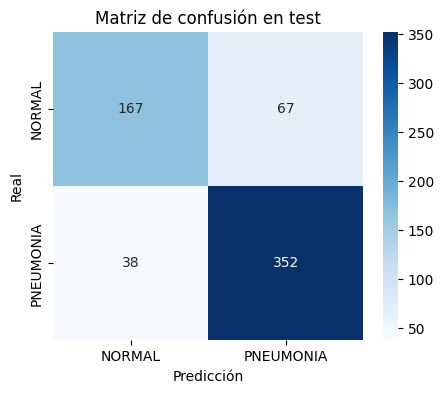

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Obtener todas las predicciones del test set (ya las tienes en all_preds, all_labels)
cm = confusion_matrix(all_labels, all_preds)
print("Matriz de confusión:")
print(cm)
print("\nReporte de clasificación:")
print(classification_report(all_labels, all_preds, target_names=['NORMAL', 'PNEUMONIA']))

# Visualizar matriz de confusión
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión en test')
plt.show()